(Habiba AlAmir Mohamed - Data Science Track - Task 1: House Price Prediction).


House Price Prediction using KNN

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [16]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

df = X.copy()
df['Price'] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
knn_model = KNeighborsRegressor(n_neighbors=9, weights='distance')
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_knn)
mae = mean_absolute_error(y_test, y_pred_knn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("[INFO] KNN Model Performance Metrics")
print(f" ├─ R2 Score                   : {r2:.4f}")
print(f" ├─ Mean Absolute Error (MAE)  : ${mae * 100000:,.2f}")
print(f" └─ Root Mean Sq. Error (RMSE) : ${rmse * 100000:,.2f}")

[INFO] KNN Model Performance Metrics
 ├─ R2 Score                   : 0.6801
 ├─ Mean Absolute Error (MAE)  : $43,746.54
 └─ Root Mean Sq. Error (RMSE) : $64,741.23


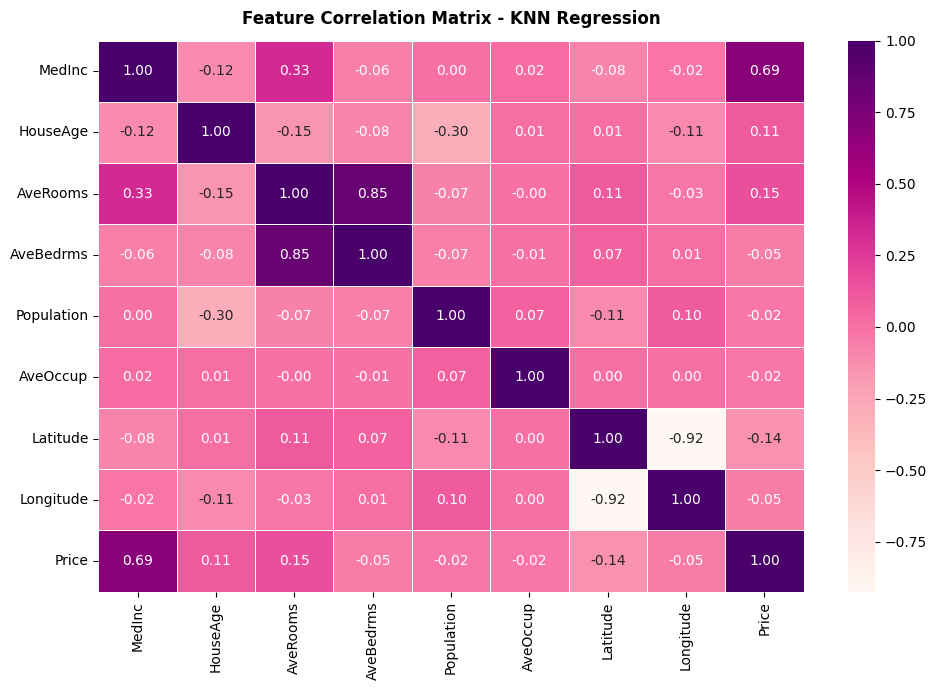

In [18]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdPu', linewidths=0.5)
plt.title('Feature Correlation Matrix - KNN Regression', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


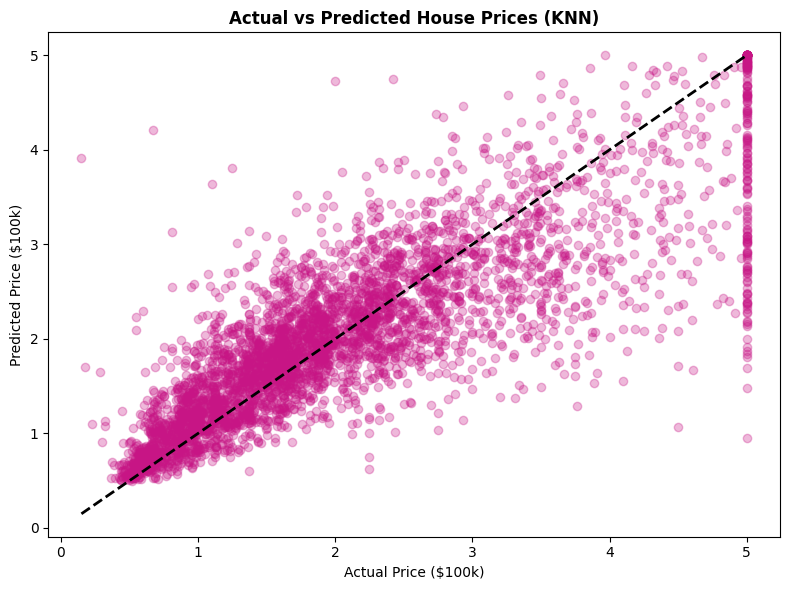

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.3, color='mediumvioletred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted House Prices (KNN)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.tight_layout()
plt.show()

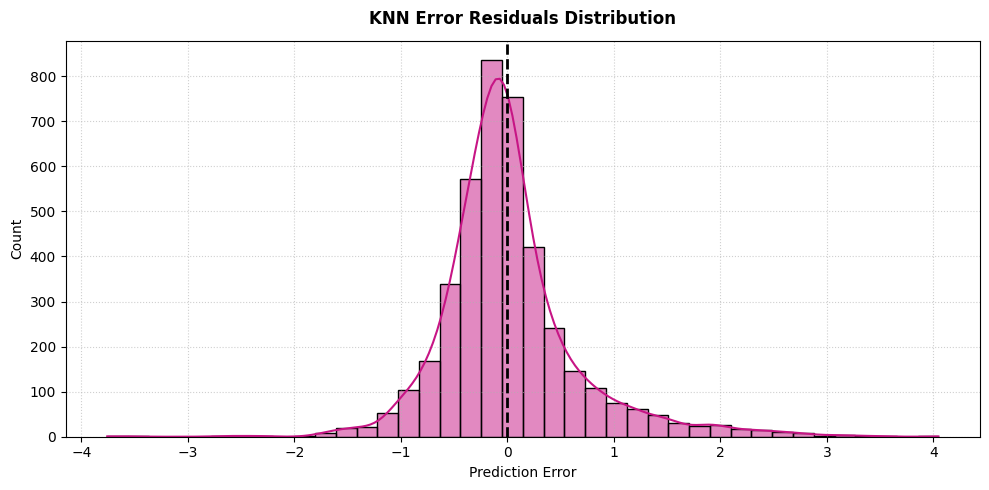

In [20]:
residuals = y_test - y_pred_knn

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='mediumvioletred', bins=40)
plt.axvline(x=0, color='black', linestyle='--', lw=2)
plt.title('KNN Error Residuals Distribution', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [21]:
new_house_features = {
    'MedInc': [6.5],
    'HouseAge': [15.0],
    'AveRooms': [6.0],
    'AveBedrms': [1.0],
    'Population': [1200.0],
    'AveOccup': [3.0],
    'Latitude': [34.05],
    'Longitude': [-118.24]
}

custom_house_df = pd.DataFrame(new_house_features)
custom_house_scaled = scaler.transform(custom_house_df)

predicted_price_knn = knn_model.predict(custom_house_scaled)[0]

print("[INFO] Live Real Estate Prediction System (KNN)")
print(f" ├─ Simulated House Age   : {new_house_features['HouseAge'][0]} Years")
print(f" ├─ Simulated Total Rooms : {new_house_features['AveRooms'][0]}")
print(f" └─ Status                : Input processed successfully\n")
print(f"»» PREDICTED MARKET VALUE : ${predicted_price_knn * 100000:,.2f} ««")

[INFO] Live Real Estate Prediction System (KNN)
 ├─ Simulated House Age   : 15.0 Years
 ├─ Simulated Total Rooms : 6.0
 └─ Status                : Input processed successfully

»» PREDICTED MARKET VALUE : $281,583.78 ««


House Price Prediction using Linear Regression

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [23]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

df = X.copy()
df['Price'] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("[INFO] Linear Regression Performance Metrics")
print(f" ├─ R2 Score                   : {r2:.4f}")
print(f" ├─ Mean Absolute Error (MAE)  : ${mae * 100000:,.2f}")
print(f" └─ Root Mean Sq. Error (RMSE) : ${rmse * 100000:,.2f}")

[INFO] Linear Regression Performance Metrics
 ├─ R2 Score                   : 0.5758
 ├─ Mean Absolute Error (MAE)  : $53,320.01
 └─ Root Mean Sq. Error (RMSE) : $74,558.14


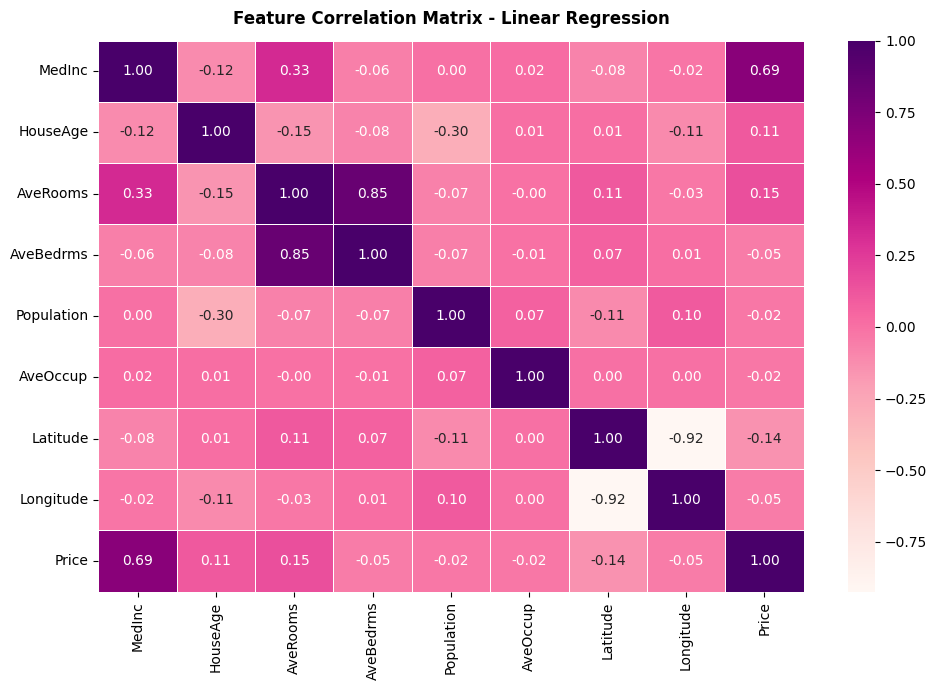

In [25]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdPu', linewidths=0.5)
plt.title('Feature Correlation Matrix - Linear Regression', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()



/tmp/ipykernel_733/1428390747.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.values, y=coefficients.index, palette='RdPu_r')


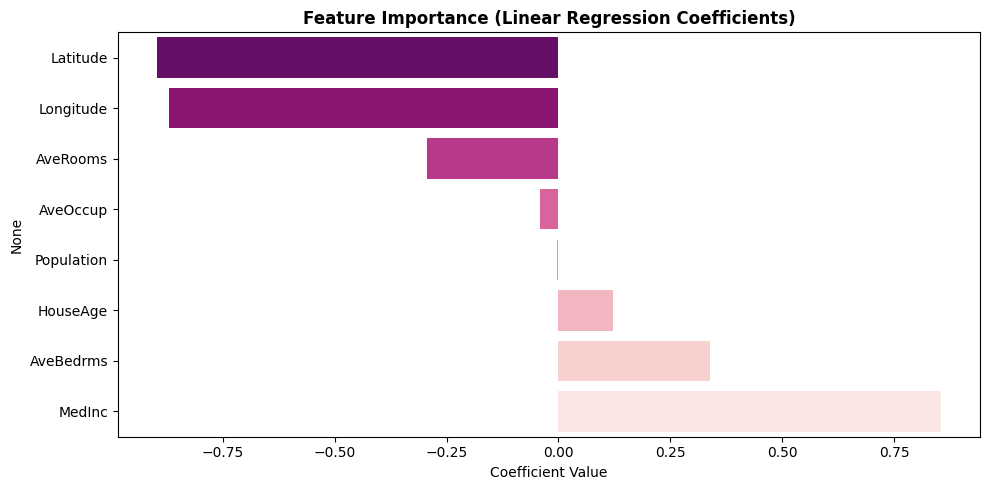

In [26]:
coefficients = pd.Series(lr_model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=coefficients.values, y=coefficients.index, palette='RdPu_r')
plt.title('Feature Importance (Linear Regression Coefficients)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


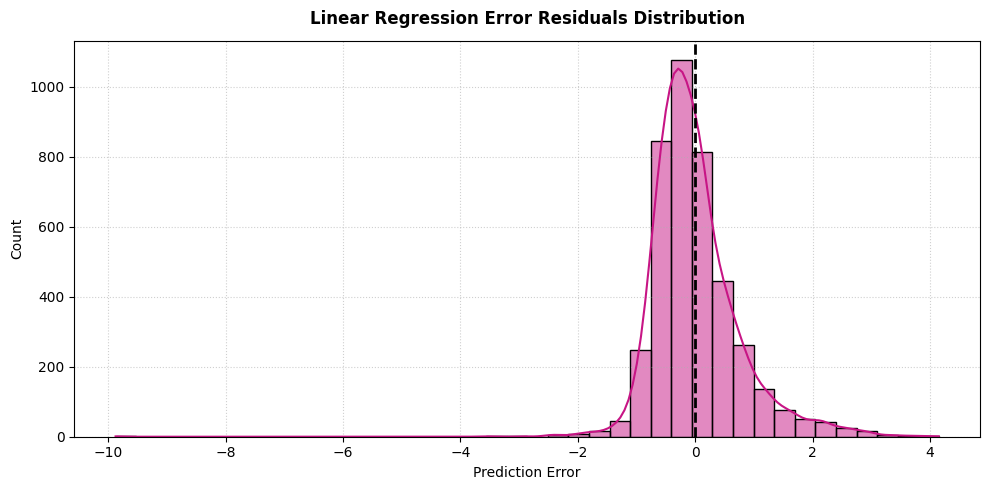

In [27]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='mediumvioletred', bins=40)
plt.axvline(x=0, color='black', linestyle='--', lw=2)
plt.title('Linear Regression Error Residuals Distribution', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:
new_house_features = {
    'MedInc': [6.5],
    'HouseAge': [15.0],
    'AveRooms': [6.0],
    'AveBedrms': [1.0],
    'Population': [1200.0],
    'AveOccup': [3.0],
    'Latitude': [34.05],
    'Longitude': [-118.24]
}

custom_house_df = pd.DataFrame(new_house_features)
custom_house_scaled = scaler.transform(custom_house_df)

predicted_price = lr_model.predict(custom_house_scaled)[0]

print("[INFO] Live Real Estate Prediction System (Linear Regression)")
print(f" ├─ Simulated House Age   : {new_house_features['HouseAge'][0]} Years")
print(f" ├─ Simulated Total Rooms : {new_house_features['AveRooms'][0]}")
print(f" └─ Status                : Input processed successfully\n")
print(f"»» PREDICTED MARKET VALUE : ${predicted_price * 100000:,.2f} ««")


[INFO] Live Real Estate Prediction System (Linear Regression)
 ├─ Simulated House Age   : 15.0 Years
 ├─ Simulated Total Rooms : 6.0
 └─ Status                : Input processed successfully

»» PREDICTED MARKET VALUE : $305,687.09 ««
